In [1]:
import h5py
from scipy.io import whosmat, loadmat
import numpy as np
import pickle
from himalaya.ridge import RidgeCV


In [2]:
base_path = "/srv/nfs-data/sisko/storage/fMRI_maas_2023"
math_path = base_path + "/Beta2hem.mat"

saved_path = "/srv/nfs-data/sisko/matteoc/maas_2023"

In [3]:
info = whosmat(math_path)

for name, shape, dtype in info:
    print(f"Variabile: {name}, shape: {shape}, tipo: {dtype}")

Variabile: BetasSEPTest, shape: (72, 1667), tipo: double
Variabile: BetasSEPTrain, shape: (216, 1667), tipo: double
Variabile: CV, shape: (1, 1), tipo: struct
Variabile: HG2hem, shape: (1, 1), tipo: struct
Variabile: InfoVTCTrain, shape: (1, 1), tipo: struct
Variabile: PP2hem, shape: (1, 1), tipo: struct
Variabile: PT2hem, shape: (1, 1), tipo: struct
Variabile: aSTG2hem, shape: (1, 1), tipo: struct
Variabile: cv, shape: (1, 1), tipo: double
Variabile: fmridirdata, shape: (1,), tipo: char
Variabile: mSTG2hem, shape: (1, 1), tipo: struct
Variabile: noCV, shape: (1, 1), tipo: double
Variabile: pSTG2hem, shape: (1, 1), tipo: struct
Variabile: reg, shape: (1, 1), tipo: double
Variabile: region, shape: (1, 1), tipo: struct
Variabile: regions_list, shape: (1, 6), tipo: cell
Variabile: s, shape: (1, 1), tipo: double
Variabile: sub, shape: (1, 1), tipo: double
Variabile: subject, shape: (1, 1), tipo: struct
Variabile: subjects_list, shape: (1, 5), tipo: cell
Variabile: testSounds, shape: (1, 72

In [4]:
def matlab_to_python(obj):
    """
    Converte ricorsivamente gli oggetti MATLAB letti da loadmat
    in strutture Python più leggibili:
    - struct MATLAB -> dict
    - cell array -> list
    - ndarray numerici -> ndarray
    - stringhe/scalari -> valori Python
    """
    # Struct MATLAB
    if hasattr(obj, "_fieldnames"):
        return {field: matlab_to_python(getattr(obj, field)) for field in obj._fieldnames}

    # Array numpy
    elif isinstance(obj, np.ndarray):
        # Array vuoto
        if obj.size == 0:
            return obj

        # Cell array o object array -> prova a convertirlo in lista
        if obj.dtype == object:
            if obj.ndim == 0:
                return matlab_to_python(obj.item())
            return [matlab_to_python(x) for x in obj.flat]

        # Array con un solo elemento -> scalar Python se possibile
        if obj.size == 1:
            try:
                return obj.item()
            except Exception:
                return obj

        return obj

    # Altri tipi: lascia così
    else:
        return obj

In [5]:
# Caricamento e conversione
raw_data = loadmat(math_path, struct_as_record=False, squeeze_me=True)
raw_data = {k: v for k, v in raw_data.items() if not k.startswith("__")}
data = {k: matlab_to_python(v) for k, v in raw_data.items()}

In [6]:
data["BetasSEPTrain"], data["BetasSEPTrain"].shape

(array([[ 1.4633024 ,  1.10715161,  1.57136241, ..., -0.12419284,
          0.0512253 ,  0.06037326],
        [ 1.58216144,  0.44355982,  1.62376205, ...,  0.16547049,
         -0.06590446,  0.08509112],
        [ 1.75557749,  1.13421204,  1.57125996, ...,  0.22550674,
         -0.02461643,  0.01483191],
        ...,
        [ 0.74571096,  0.72509141,  0.79952726, ..., -0.02687553,
          0.09386834, -0.08613259],
        [-0.33454996,  0.30133848, -0.0746192 , ...,  0.08894565,
         -0.16257438,  0.13024702],
        [-0.01495296,  0.27152439,  0.30373166, ..., -0.11780104,
          0.24168938,  0.19012366]]),
 (216, 1667))

In [7]:
data["InfoVTCTrain"], data["InfoVTCTrain"]["voxVTC"].shape

({'voxVTC': array([ 368260,  389141,  368261, ..., 2541354, 2458003, 2625212],
        dtype=int32),
  'Resolution': 1,
  'DimVTC': array([174, 120, 138], dtype=uint8)},
 (1667,))

In [8]:
# Liste di ROI e soggetti
roi_list = data["regions_list"]
subject_list = data["subjects_list"]
cv_list = ["CV1", "CV2", "CV3", "CV4"]

# Dizionario finale
data_by_subject = {}

for subj in subject_list:
    data_by_subject[subj] = {}

    for roi in roi_list:
        data_by_subject[subj][roi] = {}

        roi_struct = data[roi]   # es. data["HG2hem"]

        for cv in cv_list:
            if cv not in roi_struct:
                continue
            if subj not in roi_struct[cv]:
                continue

            subj_data = roi_struct[cv][subj]

            X_train = subj_data.get("BetasTrain", None)
            X_test = subj_data.get("BetasTest", None)
            train_sounds = subj_data.get("trainSounds", None)
            test_sounds = subj_data.get("testSounds", None)
            info_vtc = subj_data.get("InfoVTC", None)

            data_by_subject[subj][roi][cv] = {
                "X_train": X_train,
                "X_test": X_test,
                "train_sounds": train_sounds,
                "test_sounds": test_sounds,
                "info_vtc": info_vtc,
            }

print("Estrazione completata.")

Estrazione completata.


In [9]:
print(subject_list)
print(roi_list)

['KV', 'RS', 'RS1', 'RS2', 'RS3']
['HG2hem', 'PT2hem', 'PP2hem', 'mSTG2hem', 'pSTG2hem', 'aSTG2hem']


In [ ]:
subj = "KV"
roi = "pSTG2hem"
cv = "CV2"

entry = data_by_subject[subj][roi][cv]
print(entry["info_vtc"]['voxVTC'])
print(entry["info_vtc"]['DimVTC'])

print("Subject:", subj)
print("ROI:", roi)
print("CV:", cv)

print("X_train shape:", entry["X_train"].shape if entry["X_train"] is not None else None)
print("X_test shape:", entry["X_test"].shape if entry["X_test"] is not None else None)
print("train_sounds shape:", entry["train_sounds"].shape if hasattr(entry["train_sounds"], "shape") else type(entry["train_sounds"]))
print("test_sounds shape:", entry["test_sounds"].shape if hasattr(entry["test_sounds"], "shape") else type(entry["test_sounds"]))

print("train_sounds preview:", entry["train_sounds"][:10] if entry["train_sounds"] is not None else None)
print("test_sounds preview:", entry["test_sounds"][:10] if entry["test_sounds"] is not None else None)

In [11]:
subj = "RS3"
roi = "pSTG2hem" # "PT2hem"
cv = "CV2"

entry = data_by_subject[subj][roi][cv]
print(entry.keys())
print(entry["info_vtc"]['voxVTC'])
print(entry["info_vtc"]['DimVTC'])

print("Subject:", subj)
print("ROI:", roi)
print("CV:", cv)

print("X_train shape:", entry["X_train"].shape if entry["X_train"] is not None else None)
print("X_test shape:", entry["X_test"].shape if entry["X_test"] is not None else None)
print("train_sounds shape:", entry["train_sounds"].shape if hasattr(entry["train_sounds"], "shape") else type(entry["train_sounds"]))
print("test_sounds shape:", entry["test_sounds"].shape if hasattr(entry["test_sounds"], "shape") else type(entry["test_sounds"]))

print("train_sounds preview:", entry["train_sounds"][:10] if entry["train_sounds"] is not None else None)
print("test_sounds preview:", entry["test_sounds"][:10] if entry["test_sounds"] is not None else None)

dict_keys(['X_train', 'X_test', 'train_sounds', 'test_sounds', 'info_vtc'])
[ 241788  157400  157401 ... 2642660 2516860 2561217]
[174 120 138]
Subject: RS3
ROI: pSTG2hem
CV: CV2
X_train shape: (216, 3971)
X_test shape: (72, 3971)
train_sounds shape: (216,)
test_sounds shape: (72,)
train_sounds preview: [ 4  5  6  7  8  9 10 13 14 15]
test_sounds preview: [ 1  2  3 11 12 23 25 27 28 36]


In [12]:
entry["test_sounds"]

array([  1,   2,   3,  11,  12,  23,  25,  27,  28,  36,  38,  46,  51,
        55,  58,  60,  71,  73,  76,  77,  80,  85,  87,  88, 103, 104,
       105, 115, 118, 120, 126, 128, 129, 131, 132, 136, 163, 164, 165,
       166, 169, 174, 175, 176, 179, 181, 191, 192, 193, 195, 200, 201,
       205, 214, 221, 225, 229, 230, 231, 235, 241, 242, 246, 252, 256,
       258, 264, 266, 267, 268, 275, 282], dtype=uint16)

## Extract Audios

In [6]:
import re

def soundname_to_wav(sound_name: str) -> str:
    """
    Converte una stringa tipo:
    'stim145_cat04_music_exemp01'
    in:
    's2_music_1.wav'
    """
    m = re.match(r"stim\d+_cat\d+_([a-zA-Z]+)_exemp(\d+)", sound_name)
    if m is None:
        raise ValueError(f"Formato inatteso: {sound_name}")

    category = m.group(1).lower()
    exemp = int(m.group(2))

    return f"s2_{category}_{exemp}.wav"

In [12]:
wav_dir = "/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav"
name_sounds = np.load("/home/matteoc/brainSounds/maas_data/SoundNames.npy")

In [14]:
idx_train = entry["train_sounds"].astype(int) - 1
idx_test  = entry["test_sounds"].astype(int) - 1

In [ ]:
import os
import numpy as np

train_wav_paths = [
    os.path.join(wav_dir, soundname_to_wav(name_sounds[i]))
    for i in idx_train
]

test_wav_paths = [
    os.path.join(wav_dir, soundname_to_wav(name_sounds[i]))
    for i in idx_test
]

In [14]:
import os
from pathlib import Path
import tqdm
import torch
import torchaudio
from transformers import ClapModel, ClapProcessor


def load_clap_model(
    model_name: str = "laion/larger_clap_music_and_speech",
    device: str | None = None,
):
    """
    Carica modello e processor CLAP.
    get_audio_features(...) restituisce direttamente l'embedding proiettato.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    processor = ClapProcessor.from_pretrained(model_name)
    model = ClapModel.from_pretrained(model_name).to(device)
    model.eval()

    return model, processor, device


def load_audio_mono_resampled(wav_path: str, target_sr: int):
    """
    Carica un wav, lo converte in mono e lo resampla a target_sr.
    Restituisce un numpy array 1D.
    """
    audio, sr = torchaudio.load(wav_path)  # [channels, time]

    # mono
    if audio.shape[0] > 1:
        audio = audio.mean(dim=0, keepdim=True)

    # resample
    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
        audio = resampler(audio)

    return audio.squeeze(0).numpy()


@torch.no_grad()
def extract_clap_projected_embeddings(
    wav_paths,
    model,
    processor,
    device,
    batch_size: int = 8,
):
    """
    Estrae embedding CLAP audio proiettati in 512 dimensioni.

    Args:
        wav_paths: lista di path wav
        model: ClapModel
        processor: ClapProcessor
        device: 'cuda' o 'cpu'
        batch_size: batch size per inference

    Returns:
        embeddings: torch.Tensor [N, 512]
    """
    all_embeddings = []

    # sampling rate attesa dal processor / feature extractor
    target_sr = processor.feature_extractor.sampling_rate

    for start in tqdm.tqdm(range(0, len(wav_paths), batch_size)):
        batch_paths = wav_paths[start:start + batch_size]

        audios = []
        for wav_path in batch_paths:
            audio_np = load_audio_mono_resampled(wav_path, target_sr=target_sr)
            audios.append(audio_np)

        inputs = processor(
            audios=audios,
            sampling_rate=target_sr,
            return_tensors="pt",
            padding=True
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}
        audio_embeds = model.get_audio_features(**inputs)

        all_embeddings.append(audio_embeds.cpu())

    embeddings = torch.cat(all_embeddings, dim=0)
    return embeddings

In [17]:
import torch.nn.functional as F

model, processor, device = load_clap_model(
    model_name="laion/larger_clap_general"
)

test_audio_embeds = extract_clap_projected_embeddings(
    wav_paths=test_wav_paths,
    model=model,
    processor=processor,
    device=device,
    batch_size=8
)

train_audio_embeds = extract_clap_projected_embeddings(
    wav_paths=train_wav_paths,
    model=model,
    processor=processor,
    device=device,
    batch_size=8
)

train_audio_embeds = F.normalize(train_audio_embeds, dim=1).cpu().numpy()
test_audio_embeds  = F.normalize(test_audio_embeds, dim=1).cpu().numpy()

print(train_audio_embeds.shape) 
print(test_audio_embeds.shape) 

100%|██████████| 27/27 [00:06<00:00,  4.30it/s]

(216, 512)
(72, 512)


## Concat Subjects

In [18]:
import numpy as np
from sklearn.model_selection import KFold
from himalaya.ridge import RidgeCV
from collections import defaultdict
import os


def fast_corr(a, b):
    """
    Pearson correlation vettorializzata colonna per colonna
    a,b shape = (samples, voxels)
    """
    a = a - a.mean(axis=0)
    b = b - b.mean(axis=0)

    num = np.sum(a * b, axis=0)
    den = np.sqrt(np.sum(a**2, axis=0) * np.sum(b**2, axis=0)) + 1e-8

    return num / den


def voxel_selection_pool(
    data_by_subject,
    subject_list,
    roi_list,
    cv_list,
    k_voxels=1500,
    n_folds=5,
    alphas=[0.1,1,10,20,100,1000]
):

    pooled_data = defaultdict(dict)

    for roi in tqdm.tqdm(roi_list):
        for cv in cv_list:

            X_train_all = []
            X_test_all = []

            train_sounds_all = []
            test_sounds_all = []

            subjects_train = []
            subjects_test = []

            valid_subjects = []

            for subj in subject_list:

                if subj not in data_by_subject:
                    continue
                if roi not in data_by_subject[subj]:
                    continue
                if cv not in data_by_subject[subj][roi]:
                    continue

                entry = data_by_subject[subj][roi][cv]

                X_train = entry["X_train"]
                X_test = entry["X_test"]

                if X_train is None or X_test is None:
                    continue

                X_train = np.asarray(X_train)
                X_test = np.asarray(X_test)

                idx_train = entry["train_sounds"].astype(int) - 1
                train_wav_paths = [
                    os.path.join(wav_dir, soundname_to_wav(name_sounds[i]))
                    for i in idx_train
                ]
                Y_train_audio = extract_clap_projected_embeddings(
                    wav_paths=train_wav_paths,
                    model=model,
                    processor=processor,
                    device=device,
                    batch_size=8
                )
                
                # -----------------------
                # standardizzazione
                # -----------------------

                mean = X_train.mean(axis=0, keepdims=True)
                std = X_train.std(axis=0, keepdims=True)
                std[std == 0] = 1

                X_train = (X_train - mean) / std
                X_test = (X_test - mean) / std

                # -----------------------
                # encoding model
                # -----------------------

                ridge = RidgeCV(alphas=alphas)

                kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

                pred_oof = np.zeros_like(X_train)

                for train_idx, val_idx in kf.split(X_train):

                    ridge.fit(Y_train_audio[train_idx], X_train[train_idx])

                    pred_oof[val_idx] = ridge.predict(Y_train_audio[val_idx])

                # -----------------------
                # voxel scoring
                # -----------------------

                voxel_r = fast_corr(pred_oof, X_train)

                topk = np.argsort(voxel_r)[::-1][:k_voxels]

                # -----------------------
                # selezione voxel
                # -----------------------

                X_train_sel = X_train[:, topk]
                X_test_sel = X_test[:, topk]

                X_train_all.append(X_train_sel)
                X_test_all.append(X_test_sel)

                train_sounds_all.append(entry["train_sounds"])
                test_sounds_all.append(entry["test_sounds"])

                subjects_train.extend([subj] * X_train_sel.shape[0])
                subjects_test.extend([subj] * X_test_sel.shape[0])

                valid_subjects.append(subj)

                print(
                    f"{subj} | {roi} | {cv} -> "
                    f"orig_vox={X_train.shape[1]} "
                    f"selected={len(topk)} "
                    f"mean_r={voxel_r[topk].mean():.3f}"
                )

            if len(X_train_all) == 0:
                print(f"[SKIP] ROI={roi}, CV={cv}")
                continue

            X_train_concat = np.concatenate(X_train_all, axis=0)
            X_test_concat = np.concatenate(X_test_all, axis=0)

            train_sounds_concat = np.concatenate(train_sounds_all)
            test_sounds_concat = np.concatenate(test_sounds_all)

            pooled_data[roi][cv] = {

                "X_train": X_train_concat,
                "X_test": X_test_concat,

                "train_sounds": train_sounds_concat,
                "test_sounds": test_sounds_concat,

                "subjects_train": np.array(subjects_train),
                "subjects_test": np.array(subjects_test),

                "valid_subjects": valid_subjects
            }

            print(
                f"[OK] ROI={roi}, CV={cv} | "
                f"subjects={len(valid_subjects)} | "
                f"X_train={X_train_concat.shape} | "
                f"X_test={X_test_concat.shape}"
            )

    return pooled_data

In [ ]:
pooled_data = voxel_selection_pool(
    data_by_subject=data_by_subject,
    subject_list=subject_list,
    roi_list=roi_list,
    cv_list=cv_list,
    n_folds=2,
    k_voxels=1024
)

In [7]:
import pickle

# with open(saved_path + "/pooled_data.pkl", "wb") as f:
#     pickle.dump(pooled_data, f)

with open(saved_path + "/pooled_data.pkl", "rb") as f:
    pooled_data = pickle.load(f)

In [149]:
# PT2hem     HG2hem      mSTG2hem    pSTG2hem        PP2hem     aSTG2hem 

roi = 'aSTG2hem' 
cv = 'CV2'

entry = pooled_data[roi][cv]
print(entry.keys())

print("ROI:", roi)
print("CV:", cv)

print("X_train shape:", entry["X_train"].shape if entry["X_train"] is not None else None)
print("X_test shape:", entry["X_test"].shape if entry["X_test"] is not None else None)
print("train_sounds shape:", entry["train_sounds"].shape if hasattr(entry["train_sounds"], "shape") else type(entry["train_sounds"]))
print("test_sounds shape:", entry["test_sounds"].shape if hasattr(entry["test_sounds"], "shape") else type(entry["test_sounds"]))

print("train_sounds preview:", entry["train_sounds"][:10] if entry["train_sounds"] is not None else None)
print("test_sounds preview:", entry["test_sounds"][:10] if entry["test_sounds"] is not None else None)

dict_keys(['X_train', 'X_test', 'train_sounds', 'test_sounds', 'subjects_train', 'subjects_test', 'valid_subjects'])
ROI: aSTG2hem
CV: CV2
X_train shape: (1080, 1024)
X_test shape: (360, 1024)
train_sounds shape: (1080,)
test_sounds shape: (360,)
train_sounds preview: [ 4  5  6  7  8  9 10 13 14 15]
test_sounds preview: [ 1  2  3 11 12 23 25 27 28 36]


In [314]:
import numpy as np

cv = "CV2"

# ROI disponibili
roi_list = list(pooled_data.keys())
print("ROI trovate:", roi_list)

X_train_list = []
X_test_list = []

train_sounds_ref = None
test_sounds_ref = None

for roi in roi_list:
    if cv not in pooled_data[roi]:
        print(f"[SKIP] {roi}: {cv} non trovato")
        continue

    entry = pooled_data[roi][cv]

    X_train = entry["X_train"]
    X_test = entry["X_test"]
    train_sounds = entry["train_sounds"]
    test_sounds = entry["test_sounds"]

    # Controlli base
    if X_train is None or X_test is None:
        print(f"[SKIP] {roi}: X_train o X_test è None")
        continue

    # Salvo i sounds di riferimento dalla prima ROI valida
    if train_sounds_ref is None:
        train_sounds_ref = np.array(train_sounds)
        test_sounds_ref = np.array(test_sounds)
    else:
        # Verifica che l'ordine degli stimoli sia identico tra ROI
        if not np.array_equal(train_sounds_ref, np.array(train_sounds)):
            raise ValueError(f"train_sounds non allineati per ROI {roi}")
        if not np.array_equal(test_sounds_ref, np.array(test_sounds)):
            raise ValueError(f"test_sounds non allineati per ROI {roi}")

    print(f"{roi}: X_train {X_train.shape}, X_test {X_test.shape}")

    X_train_list.append(X_train)
    X_test_list.append(X_test)

# Concatenazione lungo asse voxel
X_train_concat = np.stack(X_train_list, axis=1)
X_test_concat = np.stack(X_test_list, axis=1)

print("\nShape finali concatenate:")
print("X_train_concat:", X_train_concat.shape)
print("X_test_concat:", X_test_concat.shape)
print("train_sounds:", train_sounds_ref.shape)
print("test_sounds:", test_sounds_ref.shape)

ROI trovate: ['HG2hem', 'PT2hem', 'PP2hem', 'mSTG2hem', 'pSTG2hem', 'aSTG2hem']
HG2hem: X_train (1080, 1024), X_test (360, 1024)
PT2hem: X_train (1080, 1024), X_test (360, 1024)
PP2hem: X_train (1080, 1024), X_test (360, 1024)
mSTG2hem: X_train (1080, 1024), X_test (360, 1024)
pSTG2hem: X_train (1080, 1024), X_test (360, 1024)
aSTG2hem: X_train (1080, 1024), X_test (360, 1024)

Shape finali concatenate:
X_train_concat: (1080, 6, 1024)
X_test_concat: (360, 6, 1024)
train_sounds: (1080,)
test_sounds: (360,)


In [315]:
import numpy as np

entry = pooled_data[roi][cv]

# X_test = entry["X_test"]
X_test = X_test_concat
# test_sounds = entry["test_sounds"]
test_sounds = test_sounds_ref
subjects_test = entry["subjects_test"]

# trova tutti gli stimoli unici
unique_sounds = np.unique(test_sounds)

X_test_avg = []
test_sounds_avg = []

for s in unique_sounds:
    
    idx = np.where(test_sounds == s)[0]
    
    X_test_avg.append(X_test[idx].mean(axis=0))
    test_sounds_avg.append(s)

X_test_avg = np.stack(X_test_avg)
test_sounds_avg = np.array(test_sounds_avg)

print("X_test_avg:", X_test_avg.shape)
print("test_sounds_avg:", test_sounds_avg.shape)

X_test_avg: (72, 6, 1024)
test_sounds_avg: (72,)


In [231]:
model, processor, device = load_clap_model(
    model_name="laion/larger_clap_general"
)

In [316]:
import os
import torch.nn.functional as F

# idx_train = entry["train_sounds"].astype(int) - 1
idx_train = train_sounds_ref.astype(int) - 1
idx_test  = test_sounds_avg.astype(int) - 1

train_wav_paths = [
    os.path.join(wav_dir, soundname_to_wav(name_sounds[i]))
    for i in idx_train
]

test_wav_paths = [
    os.path.join(wav_dir, soundname_to_wav(name_sounds[i]))
    for i in idx_test
]

test_audio_embeds = extract_clap_projected_embeddings(
    wav_paths=test_wav_paths,
    model=model,
    processor=processor,
    device=device,
    batch_size=8
)

train_audio_embeds = extract_clap_projected_embeddings(
    wav_paths=train_wav_paths,
    model=model,
    processor=processor,
    device=device,
    batch_size=8
)

train_audio_embeds = F.normalize(train_audio_embeds, dim=1).cpu().numpy()
test_audio_embeds  = F.normalize(test_audio_embeds, dim=1).cpu().numpy()

print(train_audio_embeds.shape) 
print(test_audio_embeds.shape) 

Extracting CLAP: 100%|██████████| 135/135 [00:17<00:00,  7.71it/s]

(1080, 512)
(72, 512)


In [317]:
print(X_train_concat.shape)
print(X_test_avg.shape)
print(train_audio_embeds.shape)
print(test_audio_embeds.shape)


(1080, 6, 1024)
(72, 6, 1024)
(1080, 512)
(72, 512)


## RSA

In [111]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

def to_tensor(x):
    if isinstance(x, np.ndarray):
        return torch.tensor(x, dtype=torch.float32)
    return x.float()

def compute_similarity_matrix(X, metric="cosine"):
    X = to_tensor(X)

    if metric == "cosine":
        X = F.normalize(X, p=2, dim=1)
        sim = X @ X.T
    elif metric == "pearson":
        X = X - X.mean(dim=1, keepdim=True)
        X = F.normalize(X, p=2, dim=1)
        sim = X @ X.T
    else:
        raise ValueError("metric deve essere 'cosine' o 'pearson'")

    return sim.cpu().numpy()

def similarity_to_rdm(sim):
    return 1.0 - sim

def get_upper_triangle_values(mat):
    idx = np.triu_indices(mat.shape[0], k=1)
    return mat[idx]

def plot_similarity_matrices(mat1, mat2, title1="Matrix 1", title2="Matrix 2"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    im1 = axes[0].imshow(mat1, aspect='auto')
    axes[0].set_title(title1)
    axes[0].set_xlabel("Stimuli")
    axes[0].set_ylabel("Stimuli")
    plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

    im2 = axes[1].imshow(mat2, aspect='auto')
    axes[1].set_title(title2)
    axes[1].set_xlabel("Stimuli")
    axes[1].set_ylabel("Stimuli")
    plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

def rsa_permutation_test(rdm_brain, rdm_audio, corr_type="spearman", n_perm=1000, random_state=42):
    rng = np.random.default_rng(random_state)

    v_brain = get_upper_triangle_values(rdm_brain)
    v_audio = get_upper_triangle_values(rdm_audio)

    if corr_type == "spearman":
        observed_corr, _ = spearmanr(v_brain, v_audio)
    elif corr_type == "pearson":
        observed_corr, _ = pearsonr(v_brain, v_audio)
    else:
        raise ValueError("corr_type deve essere 'spearman' o 'pearson'")

    null_distribution = []
    N = rdm_audio.shape[0]

    for _ in range(n_perm):
        perm = rng.permutation(N)
        permuted_rdm_audio = rdm_audio[perm][:, perm]
        v_perm = get_upper_triangle_values(permuted_rdm_audio)

        if corr_type == "spearman":
            perm_corr, _ = spearmanr(v_brain, v_perm)
        else:
            perm_corr, _ = pearsonr(v_brain, v_perm)

        null_distribution.append(perm_corr)

    null_distribution = np.array(null_distribution)

    p_value_one_sided = (np.sum(null_distribution >= observed_corr) + 1) / (n_perm + 1)
    p_value_two_sided = (np.sum(np.abs(null_distribution) >= np.abs(observed_corr)) + 1) / (n_perm + 1)

    return observed_corr, p_value_one_sided, p_value_two_sided, null_distribution

def plot_null_distribution(null_distribution, observed_corr, title="RSA permutation test"):
    plt.figure(figsize=(7, 5))
    plt.hist(null_distribution, bins=30)
    plt.axvline(observed_corr, linestyle='--', linewidth=2, label=f'Observed = {observed_corr:.3f}')
    plt.xlabel("Correlation")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

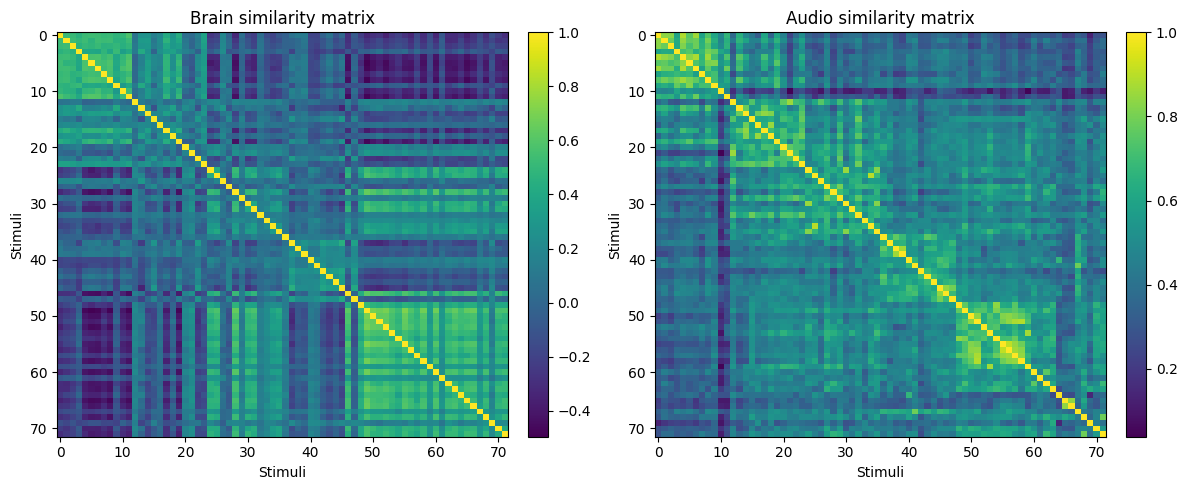

Observed RSA correlation: 0.4795
Permutation p-value (one-sided): 0.0010
Permutation p-value (two-sided): 0.0010


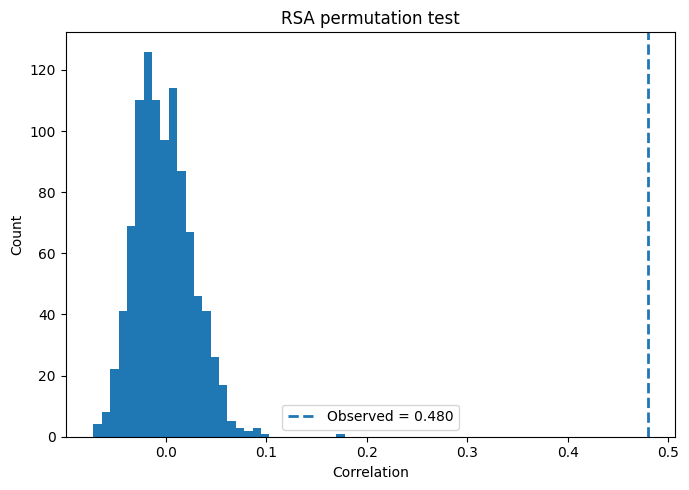

In [112]:
X_brain = X_test_avg      
X_audio = test_audio_embeds    

# Similarity matrices
sim_brain = compute_similarity_matrix(X_brain, metric="cosine")
sim_audio = compute_similarity_matrix(X_audio, metric="cosine")

plot_similarity_matrices(sim_brain, sim_audio,
                         title1="Brain similarity matrix",
                         title2="Audio similarity matrix")

# RDMs
rdm_brain = similarity_to_rdm(sim_brain)
rdm_audio = similarity_to_rdm(sim_audio)

# RSA significance
obs_corr, p_one, p_two, null_dist = rsa_permutation_test(
    rdm_brain, rdm_audio,
    corr_type="spearman",
    n_perm=1000,
    random_state=42
)

print(f"Observed RSA correlation: {obs_corr:.4f}")
print(f"Permutation p-value (one-sided): {p_one:.4f}")
print(f"Permutation p-value (two-sided): {p_two:.4f}")

plot_null_distribution(null_dist, obs_corr)

## Model

In [113]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from himalaya.ridge import RidgeCV
from himalaya.kernel_ridge import KernelRidgeCV
from sklearn.linear_model import Ridge
import torch
import numpy as np

train_mean_fmri = X_train_concat.mean(axis=0, keepdims=True)
train_std_fmri  = X_train_concat.std(axis=0, keepdims=True)
train_std_fmri[train_std_fmri == 0] = 1.0

X_train = (X_train_concat - train_mean_fmri) / train_std_fmri
X_test  = (X_test_avg  - train_mean_fmri) / train_std_fmri

Y_train = train_audio_embeds
Y_test = test_audio_embeds

# alphas = np.logspace(-4, 5, 200)
alphas = [0.1,1,10,20,100,1000]

pipeline = Pipeline([
    ("ridge", RidgeCV(alphas=alphas))
])

pipeline.fit(X_train, Y_train)
voxels_scores=pipeline.score(X_train, Y_train)

test_audio_pred = pipeline.predict(X_test)

/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/himalaya/ridge/_random_search.py:491: UserWarning: Solving ridge is slower than solving kernel ridge when n_samples < n_features (here 1080 < 6144). Using a linear kernel in himalaya.kernel_ridge.KernelRidgeCV or himalaya.kernel_ridge.solve_kernel_ridge_cv_eigenvalues would be faster. Use warn=False to silence this warning.
  warnings.warn(


Mean cosine similarity: 0.36061475260330705
Median cosine similarity: 0.3646957838582955


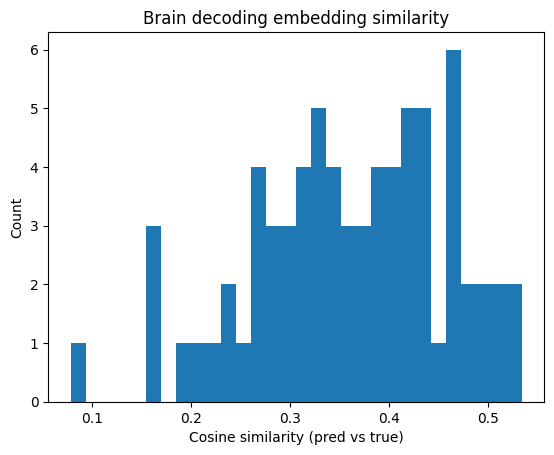

In [114]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

sim = np.diag(cosine_similarity(test_audio_pred, Y_test))

print("Mean cosine similarity:", sim.mean())
print("Median cosine similarity:", np.median(sim))

plt.hist(sim, bins=30)
plt.xlabel("Cosine similarity (pred vs true)")
plt.ylabel("Count")
plt.title("Brain decoding embedding similarity")
plt.show()

In [115]:
random_idx = np.random.permutation(len(Y_test))

random_sim = np.diag(
    cosine_similarity(test_audio_pred, Y_test[random_idx])
)

print("True mean similarity:", sim.mean())
print("Random mean similarity:", random_sim.mean())

True mean similarity: 0.36061475260330705
Random mean similarity: 0.03216905086076868


In [116]:
from sklearn.neighbors import NearestNeighbors

Y_test_norm = Y_test / np.linalg.norm(Y_test, axis=1, keepdims=True)
test_audio_pred = test_audio_pred / np.linalg.norm(test_audio_pred, axis=1, keepdims=True)

nbrs = NearestNeighbors(n_neighbors=5, metric="cosine").fit(Y_test_norm)
distances, top_indices = nbrs.kneighbors(test_audio_pred)

top1 = np.mean(top_indices[:, 0] == np.arange(len(top_indices)))
top5 = np.mean([i in top_indices[i] for i in range(len(top_indices))])

print("Top-1:", top1)
print("Top-5:", top5)

Top-1: 0.20833333333333334
Top-5: 0.625


Text(0.5, 1.0, 'Predicted vs True embeddings')

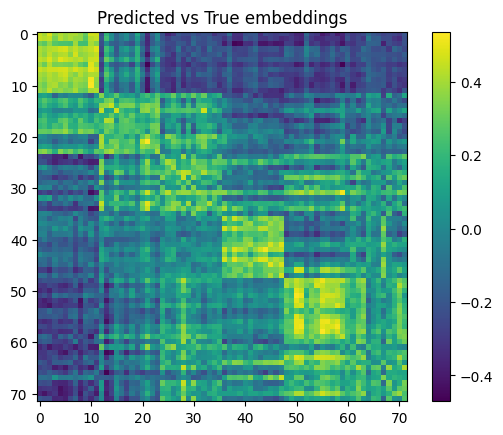

In [117]:
plt.imshow(cosine_similarity(test_audio_pred, Y_test))
plt.colorbar()
plt.title("Predicted vs True embeddings")

In [ ]:
# CV1
# Top-1: 0.1311111111111111
# Top-5: 0.5061111111111111

# CV2
# Top-1: 0.20833333333333334
# Top-5: 0.625

# CV3
# Top-1: 0.18055555555555555
# Top-5: 0.5416666666666666

# CV4
# Top-1: 0.18055555555555555
# Top-5: 0.5833333333333334

## Final Loop

In [126]:
import os
import re
import json
import pickle
import numpy as np
import pandas as pd
import torch
import torchaudio
import tqdm
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

from himalaya.kernel_ridge import KernelRidgeCV
from transformers import ClapModel, ClapProcessor
import torch.nn.functional as F


# =========================================================
# 1. AUDIO / CLAP HELPERS
# =========================================================

def soundname_to_wav(sound_name: str) -> str:
    """
    Esempio:
    'stim145_cat04_music_exemp01' -> 's2_music_1.wav'
    """
    m = re.match(r"stim\d+_cat\d+_([a-zA-Z]+)_exemp(\d+)", sound_name)
    if m is None:
        raise ValueError(f"Formato inatteso: {sound_name}")

    category = m.group(1).lower()
    exemp = int(m.group(2))
    return f"s2_{category}_{exemp}.wav"


def load_clap_model(
    model_name: str = "laion/larger_clap_general",
    device: str | None = None,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    processor = ClapProcessor.from_pretrained(model_name)
    model = ClapModel.from_pretrained(model_name).to(device)
    model.eval()
    return model, processor, device


def load_audio_mono_resampled(wav_path: str, target_sr: int):
    audio, sr = torchaudio.load(wav_path)  # [channels, time]

    if audio.shape[0] > 1:
        audio = audio.mean(dim=0, keepdim=True)

    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
        audio = resampler(audio)

    return audio.squeeze(0).numpy()


@torch.no_grad()
def extract_clap_projected_embeddings(
    wav_paths,
    model,
    processor,
    device,
    batch_size: int = 8,
):
    all_embeddings = []
    target_sr = processor.feature_extractor.sampling_rate

    for start in tqdm.tqdm(range(0, len(wav_paths), batch_size), desc="Extracting CLAP"):
        batch_paths = wav_paths[start:start + batch_size]

        audios = []
        for wav_path in batch_paths:
            audio_np = load_audio_mono_resampled(wav_path, target_sr=target_sr)
            audios.append(audio_np)

        inputs = processor(
            audios=audios,
            sampling_rate=target_sr,
            return_tensors="pt",
            padding=True
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}
        audio_embeds = model.get_audio_features(**inputs)
        all_embeddings.append(audio_embeds.cpu())

    embeddings = torch.cat(all_embeddings, dim=0)
    return embeddings


def precompute_all_audio_embeddings(
    sound_names_path,
    wav_dir,
    model,
    processor,
    device,
    batch_size=8
):
    """
    Precalcola UNA volta sola gli embedding CLAP per tutti i 288 suoni.
    """
    name_sounds = np.load(sound_names_path)

    all_wav_paths = [
        os.path.join(wav_dir, soundname_to_wav(name))
        for name in name_sounds
    ]

    missing = [p for p in all_wav_paths if not os.path.exists(p)]
    if len(missing) > 0:
        raise FileNotFoundError(f"Mancano {len(missing)} wav. Esempi: {missing[:10]}")

    all_audio_embeds = extract_clap_projected_embeddings(
        wav_paths=all_wav_paths,
        model=model,
        processor=processor,
        device=device,
        batch_size=batch_size
    )

    all_audio_embeds = F.normalize(all_audio_embeds, dim=1).cpu().numpy()
    return name_sounds, all_audio_embeds


# =========================================================
# 2. FMRI HELPERS
# =========================================================

def average_test_by_sound(X_test, test_sounds):
    """
    Media X_test sui soggetti per ciascun suono test.
    Input:
        X_test: (n_subjects * 72, n_voxels)
        test_sounds: (n_subjects * 72,)
    Output:
        X_test_avg: (72, n_voxels)
        test_sounds_avg: (72,)
    """
    unique_sounds = np.unique(test_sounds)

    X_test_avg = []
    test_sounds_avg = []

    for s in unique_sounds:
        idx = np.where(test_sounds == s)[0]
        X_test_avg.append(X_test[idx].mean(axis=0))
        test_sounds_avg.append(s)

    X_test_avg = np.vstack(X_test_avg)
    test_sounds_avg = np.array(test_sounds_avg)

    return X_test_avg, test_sounds_avg


def zscore_train_test(X_train, X_test):
    train_mean = X_train.mean(axis=0, keepdims=True)
    train_std = X_train.std(axis=0, keepdims=True)
    train_std[train_std == 0] = 1.0

    X_train_z = (X_train - train_mean) / train_std
    X_test_z = (X_test - train_mean) / train_std

    return X_train_z, X_test_z, train_mean, train_std


# =========================================================
# 3. EVALUATION PIPELINE
# =========================================================

def evaluate_all_rois_mean_over_cvs(
    pooled_data,
    roi_list,
    cv_list,
    all_audio_embeds,
    name_sounds,
    alphas=(0.1, 1, 10, 20, 100, 1000),
    output_dir="./decoding_results",
    n_neighbors=5,
):
    """
    Per ogni ROI e CV:
      - media test fMRI sui soggetti
      - costruisce Y_train / Y_test dagli indici dei suoni
      - allena ridge (KernelRidgeCV lineare, più veloce di RidgeCV qui)
      - valuta retrieval top1 / top5
      - salva retrieval details
      - accumula matrice globale 288x288 per mediare correttamente sui CV

    Restituisce:
      roi_summary_df
      cv_results_df
      retrieval_df
      roi_mean_similarity_matrices
    """
    # os.makedirs(output_dir, exist_ok=True)

    n_total_sounds = len(name_sounds)

    cv_rows = []
    retrieval_rows = []
    roi_mean_similarity_matrices = {}

    # Per ogni ROI accumulo:
    # sum_matrix[global_true_sound, global_candidate_sound]
    # count_matrix[...] numero di volte osservato sui CV
    roi_sum_mats = {}
    roi_count_mats = {}

    for roi in roi_list:
        roi_sum_mats[roi] = np.zeros((n_total_sounds, n_total_sounds), dtype=np.float64)
        roi_count_mats[roi] = np.zeros((n_total_sounds, n_total_sounds), dtype=np.float64)

        print(f"\n================ ROI: {roi} ================\n")

        for cv in cv_list:
            if roi not in pooled_data or cv not in pooled_data[roi]:
                print(f"[SKIP] ROI={roi}, CV={cv} non presente in pooled_data.")
                continue

            entry = pooled_data[roi][cv]

            X_train_raw = np.asarray(entry["X_train"])
            X_test_raw = np.asarray(entry["X_test"])
            train_sounds = np.asarray(entry["train_sounds"]).astype(int).squeeze()
            test_sounds = np.asarray(entry["test_sounds"]).astype(int).squeeze()

            # Media test sui soggetti -> 72 sample
            X_test_avg, test_sounds_avg = average_test_by_sound(X_test_raw, test_sounds)

            # Indici globali 0-based per CLAP
            idx_train = train_sounds - 1
            idx_test = test_sounds_avg - 1

            # Target audio embeddings
            Y_train = all_audio_embeds[idx_train]
            Y_test = all_audio_embeds[idx_test]

            # Z-score fMRI
            X_train, X_test, _, _ = zscore_train_test(X_train_raw, X_test_avg)

            # Modello: kernel ridge lineare (più veloce nel tuo regime)
            pipeline = Pipeline([
                ("ridge", RidgeCV(
                    alphas=np.array(alphas, dtype=np.float32),
                ))
            ])

            pipeline.fit(X_train, Y_train)
            train_score = pipeline.score(X_train, Y_train)

            test_audio_pred = pipeline.predict(X_test)

            # Normalizzazione per retrieval / cosine
            Y_test_norm = Y_test / np.linalg.norm(Y_test, axis=1, keepdims=True)
            test_audio_pred_norm = test_audio_pred / np.linalg.norm(test_audio_pred, axis=1, keepdims=True)

            # Matrice predicted vs true per questo CV (72 x 72)
            sim_matrix_local = cosine_similarity(test_audio_pred_norm, Y_test_norm)

            # Retrieval
            nbrs = NearestNeighbors(
                n_neighbors=min(n_neighbors, len(Y_test_norm)),
                metric="cosine"
            ).fit(Y_test_norm)

            distances, top_indices_local = nbrs.kneighbors(test_audio_pred_norm)

            top1 = np.mean(top_indices_local[:, 0] == np.arange(len(top_indices_local)))
            top5 = np.mean([i in top_indices_local[i] for i in range(len(top_indices_local))])
            diag_cos = np.mean(np.diag(sim_matrix_local))

            print(
                f"[ROI={roi} | CV={cv}] "
                f"X_train={X_train.shape}, X_test={X_test.shape}, "
                f"Top-1={top1:.4f}, Top-5={top5:.4f}, DiagCos={diag_cos:.4f}"
            )

            # Salvataggio risultati CV
            cv_rows.append({
                "roi": roi,
                "cv": cv,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_voxels": X_train.shape[1],
                "top1": float(top1),
                "top5": float(top5),
                "diag_cosine_mean": float(diag_cos),
            })

            # Accumulo nella matrice globale ROI-level (288 x 288)
            # Le righe/colonne di sim_matrix_local corrispondono ai suoni in idx_test
            roi_sum_mats[roi][np.ix_(idx_test, idx_test)] += sim_matrix_local
            roi_count_mats[roi][np.ix_(idx_test, idx_test)] += 1.0

            # Salva retrieval dettagliato
            for i in range(len(idx_test)):
                true_global_idx = int(idx_test[i])
                true_sound_name = str(name_sounds[true_global_idx])

                retrieved_local = top_indices_local[i]
                retrieved_global = idx_test[retrieved_local]
                retrieved_names = [str(name_sounds[g]) for g in retrieved_global]

                retrieval_rows.append({
                    "roi": roi,
                    "cv": cv,
                    "sample_local_idx": int(i),
                    "true_sound_idx_1based": int(true_global_idx + 1),
                    "true_sound_name": true_sound_name,
                    "top1_correct": bool(retrieved_local[0] == i),
                    "top5_correct": bool(i in retrieved_local),
                    "topk_local_indices": json.dumps(retrieved_local.tolist()),
                    "topk_global_sound_idx_1based": json.dumps((retrieved_global + 1).tolist()),
                    "topk_sound_names": json.dumps(retrieved_names),
                    "topk_cosine_similarities": json.dumps((1.0 - distances[i]).tolist()),
                })

    # =====================================================
    # 4. Media ROI sui CV
    # =====================================================
    cv_results_df = pd.DataFrame(cv_rows)

    roi_summary_rows = []

    for roi in tqdm.tqdm(roi_list):
        roi_cv_df = cv_results_df[cv_results_df["roi"] == roi].copy()

        if len(roi_cv_df) == 0:
            continue

        roi_summary_rows.append({
            "roi": roi,
            "n_cvs": int(len(roi_cv_df)),
            "top1_mean": roi_cv_df["top1"].mean(),
            "top1_std": roi_cv_df["top1"].std(ddof=1) if len(roi_cv_df) > 1 else 0.0,
            "top5_mean": roi_cv_df["top5"].mean(),
            "top5_std": roi_cv_df["top5"].std(ddof=1) if len(roi_cv_df) > 1 else 0.0,
            "diag_cosine_mean": roi_cv_df["diag_cosine_mean"].mean(),
            "diag_cosine_std": roi_cv_df["diag_cosine_mean"].std(ddof=1) if len(roi_cv_df) > 1 else 0.0,
            "n_voxels_mean": roi_cv_df["n_voxels"].mean(),
        })

        # matrice media globale 288x288
        sum_mat = roi_sum_mats[roi]
        count_mat = roi_count_mats[roi]

        roi_mean_similarity_matrices[roi] = sum_mat

    roi_summary_df = pd.DataFrame(roi_summary_rows).sort_values("top1_mean", ascending=False)
    retrieval_df = pd.DataFrame(retrieval_rows)

    # =====================================================
    # 5. Salvataggi
    # =====================================================
    # roi_summary_path = os.path.join(output_dir, "roi_summary_mean_over_cvs.csv")
    # cv_results_path = os.path.join(output_dir, "cv_results_all_rois.csv")
    # retrieval_path = os.path.join(output_dir, "retrieval_details_all_rois.csv")
    # matrices_path = os.path.join(output_dir, "roi_mean_similarity_matrices.pkl")

    # roi_summary_df.to_csv(roi_summary_path, index=False)
    # cv_results_df.to_csv(cv_results_path, index=False)
    # retrieval_df.to_csv(retrieval_path, index=False)

    # with open(matrices_path, "wb") as f:
    #     pickle.dump(roi_mean_similarity_matrices, f)

    # print("\n================ SAVED FILES ================\n")
    # print(roi_summary_path)
    # print(cv_results_path)
    # print(retrieval_path)
    # print(matrices_path)

    return roi_summary_df, cv_results_df, retrieval_df, roi_mean_similarity_matrices


# =========================================================
# 4. PLOT HELPER
# =========================================================

def plot_roi_mean_matrix(roi_mean_similarity_matrices, roi, figsize=(8, 6), vmin=None, vmax=None):
    """
    Visualizza la matrice media globale 288x288 per una ROI.
    Celle mai osservate nei CV restano NaN.
    """
    mat = roi_mean_similarity_matrices[roi]

    plt.figure(figsize=figsize)

    im = plt.imshow(mat, aspect="auto", vmin=vmin, vmax=vmax)
    plt.colorbar(im)

    plt.title(f"Mean Predicted vs True Cosine Matrix | ROI={roi}")
    plt.xlabel("True audio global index")
    plt.ylabel("Predicted sample global true index")

    plt.show()


# =========================================================
# 5. ESEMPIO D'USO
# =========================================================

# --- paths ---
sound_names_path = "/home/matteoc/brainSounds/maas_data/SoundNames.npy"
wav_dir = "/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav"
output_dir = "./decoding_results_all_rois"

# --- carica CLAP una volta sola ---
model, processor, device = load_clap_model(
    model_name="laion/larger_clap_general"
)

# --- precalcola embedding per tutti i 288 suoni una volta sola ---
name_sounds, all_audio_embeds = precompute_all_audio_embeddings(
    sound_names_path=sound_names_path,
    wav_dir=wav_dir,
    model=model,
    processor=processor,
    device=device,
    batch_size=8
)

# --- evaluation completa ---
roi_summary_df, cv_results_df, retrieval_df, roi_mean_similarity_matrices = evaluate_all_rois_mean_over_cvs(
    pooled_data=pooled_data,
    roi_list=roi_list,
    cv_list=['CV1', 'CV2', 'CV3', 'CV4'],
    all_audio_embeds=all_audio_embeds,
    name_sounds=name_sounds,
    alphas=(0.1, 1, 10, 20, 100, 1000),
    output_dir=output_dir,
    n_neighbors=5,
)

print("\n===== ROI SUMMARY (mean over CVs) =====")
print(roi_summary_df)

# esempio plot di una ROI
# plot_roi_mean_matrix(roi_mean_similarity_matrices, roi="pSTG2hem")

Extracting CLAP: 100%|██████████| 36/36 [00:04<00:00,  7.79it/s]



================ ROI: HG2hem ================

[ROI=HG2hem | CV=CV1] X_train=(1080, 1024), X_test=(72, 1024), Top-1=0.0417, Top-5=0.3056, DiagCos=0.2398
[ROI=HG2hem | CV=CV2] X_train=(1080, 1024), X_test=(72, 1024), Top-1=0.1250, Top-5=0.4722, DiagCos=0.2583
[ROI=HG2hem | CV=CV3] X_train=(1080, 1024), X_test=(72, 1024), Top-1=0.1528, Top-5=0.5139, DiagCos=0.2956
[ROI=HG2hem | CV=CV4] X_train=(1080, 1024), X_test=(72, 1024), Top-1=0.1806, Top-5=0.5000, DiagCos=0.2814

================ ROI: PT2hem ================

[ROI=PT2hem | CV=CV1] X_train=(1080, 1024), X_test=(72, 1024), Top-1=0.0833, Top-5=0.4167, DiagCos=0.2804
[ROI=PT2hem | CV=CV2] X_train=(1080, 1024), X_test=(72, 1024), Top-1=0.2222, Top-5=0.5833, DiagCos=0.3342
[ROI=PT2hem | CV=CV3] X_train=(1080, 1024), X_test=(72, 1024), Top-1=0.1667, Top-5=0.4583, DiagCos=0.2984
[ROI=PT2hem | CV=CV4] X_train=(1080, 1024), X_test=(72, 1024), Top-1=0.0972, Top-5=0.4583, DiagCos=0.3250

================ ROI: PP2hem ================

[ROI=PP2

100%|██████████| 6/6 [00:00<00:00, 2088.97it/s]


===== ROI SUMMARY (mean over CVs) =====
        roi  n_cvs  top1_mean  top1_std  top5_mean  top5_std  \
1    PT2hem      4   0.142361  0.064525   0.479167  0.072169   
0    HG2hem      4   0.125000  0.060007   0.447917  0.096475   
3  mSTG2hem      4   0.121528  0.034722   0.434028  0.045889   
4  pSTG2hem      4   0.100694  0.013298   0.399306  0.062500   
2    PP2hem      4   0.083333  0.011340   0.392361  0.053642   
5  aSTG2hem      4   0.048611  0.008019   0.263889  0.025358   

   diag_cosine_mean  diag_cosine_std  n_voxels_mean  
1          0.309504         0.024630         1024.0  
0          0.268774         0.024669         1024.0  
3          0.327260         0.017791         1024.0  
4          0.322452         0.020421         1024.0  
2          0.280638         0.015380         1024.0  
5          0.272221         0.010358         1024.0  


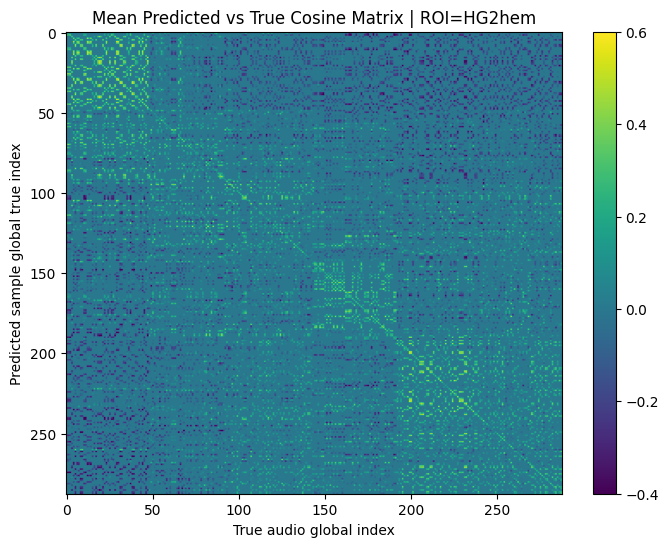

In [133]:
roi = 'HG2hem'
plot_roi_mean_matrix(roi_mean_similarity_matrices, roi, vmax=0.6, vmin=-0.4)

## Semantic Category

In [140]:
import os
import re
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tqdm

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder


# =========================================================
# 1. HELPERS
# =========================================================

def extract_semantic_category(sound_name: str) -> str:
    """
    Esempi:
    'stim001_cat01_speech_exemp01' -> 'speech'
    'stim049_cat02_voice_exemp01'  -> 'voice'
    'stim145_cat04_music_exemp01'  -> 'music'
    """
    m = re.match(r"stim\d+_cat\d+_([a-zA-Z]+)_exemp\d+", str(sound_name))
    if m is None:
        raise ValueError(f"Formato inatteso per sound name: {sound_name}")
    return m.group(1).lower()


def average_test_by_sound(X_test, test_sounds):
    """
    Media X_test sui soggetti per ciascun suono test.
    Input:
        X_test: (n_subjects * 72, n_voxels)
        test_sounds: (n_subjects * 72,)
    Output:
        X_test_avg: (72, n_voxels)
        test_sounds_avg: (72,)
    """
    unique_sounds = np.unique(test_sounds)

    X_test_avg = []
    test_sounds_avg = []

    for s in unique_sounds:
        idx = np.where(test_sounds == s)[0]
        X_test_avg.append(X_test[idx].mean(axis=0))
        test_sounds_avg.append(s)

    X_test_avg = np.vstack(X_test_avg)
    test_sounds_avg = np.array(test_sounds_avg)

    return X_test_avg, test_sounds_avg


def zscore_train_test(X_train, X_test):
    train_mean = X_train.mean(axis=0, keepdims=True)
    train_std = X_train.std(axis=0, keepdims=True)
    train_std[train_std == 0] = 1.0

    X_train_z = (X_train - train_mean) / train_std
    X_test_z = (X_test - train_mean) / train_std

    return X_train_z, X_test_z, train_mean, train_std


def plot_roi_category_confusion(
    roi_mean_confusion_matrices,
    roi,
    class_names,
    figsize=(7, 6),
    normalize=True,
    cmap="Blues"
):
    mat = roi_mean_confusion_matrices[roi].copy()

    if normalize:
        row_sums = mat.sum(axis=1, keepdims=True)
        mat = np.divide(mat, row_sums, where=row_sums != 0)

    plt.figure(figsize=figsize)
    im = plt.imshow(mat, cmap=cmap, vmin=0, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right", fontsize=10)
    plt.yticks(range(len(class_names)), class_names, fontsize=10)

    plt.xlabel("Predicted category", fontsize=12)
    plt.ylabel("True category", fontsize=12)
    plt.title(f"Mean semantic category confusion matrix\nROI={roi}", fontsize=13)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            value = mat[i, j]
            text = f"{value*100:.0f}%"
            color = "white" if value > 0.5 else "black"
            if i == j:
                plt.text(j, i, text,
                         ha="center", va="center",
                         color=color,
                         fontsize=11,
                         fontweight="bold")
            else:
                plt.text(j, i, text,
                         ha="center", va="center",
                         color=color,
                         fontsize=10)

    plt.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)
    plt.gca().set_xticks(np.arange(-.5, len(class_names), 1), minor=True)
    plt.gca().set_yticks(np.arange(-.5, len(class_names), 1), minor=True)
    plt.gca().tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout()
    plt.show()


# =========================================================
# 2. MAIN PIPELINE
# =========================================================

def evaluate_semantic_category_decoding(
    pooled_data,
    roi_list,
    cv_list,
    name_sounds,
    output_dir="./semantic_decoding_results",
    C=1.0,
    max_iter=3000,
):
    """
    Per ogni ROI e CV:
      - media il test sui soggetti
      - estrae le categorie semantiche dai nomi audio
      - allena un classificatore da fMRI -> semantic category
      - calcola accuracy, balanced accuracy, confusion matrix
      - media i risultati sui CV per ogni ROI

    Restituisce:
      roi_summary_df
      cv_results_df
      predictions_df
      roi_mean_confusion_matrices
      label_encoder
    """
    os.makedirs(output_dir, exist_ok=True)

    # -----------------------------------------------------
    # label globali da tutti i 288 suoni
    # -----------------------------------------------------
    semantic_labels_all = np.array([extract_semantic_category(x) for x in name_sounds])

    label_encoder = LabelEncoder()
    label_encoder.fit(semantic_labels_all)
    class_names = list(label_encoder.classes_)

    print("Semantic classes:", class_names)

    cv_rows = []
    prediction_rows = []

    # per ogni ROI accumulo confusion matrices dei CV
    roi_cv_confusions = {roi: [] for roi in roi_list}

    for roi in roi_list:
        print(f"\n================ ROI: {roi} ================\n")

        for cv in cv_list:
            if roi not in pooled_data or cv not in pooled_data[roi]:
                print(f"[SKIP] ROI={roi}, CV={cv} non presente in pooled_data.")
                continue

            entry = pooled_data[roi][cv]

            X_train_raw = np.asarray(entry["X_train"])
            X_test_raw = np.asarray(entry["X_test"])
            train_sounds = np.asarray(entry["train_sounds"]).astype(int).squeeze()
            test_sounds = np.asarray(entry["test_sounds"]).astype(int).squeeze()

            # media il test sui soggetti -> 72 sample
            X_test_avg, test_sounds_avg = average_test_by_sound(X_test_raw, test_sounds)

            # indici globali 0-based
            idx_train = train_sounds - 1
            idx_test = test_sounds_avg - 1

            # categorie semantiche
            y_train_str = semantic_labels_all[idx_train]
            y_test_str = semantic_labels_all[idx_test]

            y_train = label_encoder.transform(y_train_str)
            y_test = label_encoder.transform(y_test_str)

            # z-score fMRI
            X_train, X_test, _, _ = zscore_train_test(X_train_raw, X_test_avg)

            # classificatore
            clf = Pipeline([
                ("clf", LogisticRegression(
                    C=C,
                    max_iter=max_iter,
                    multi_class="multinomial",
                    solver="lbfgs",
                    class_weight="balanced",
                    n_jobs=None
                ))
            ])

            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)

            if hasattr(clf.named_steps["clf"], "predict_proba"):
                y_proba = clf.predict_proba(X_test)
                confidence = np.max(y_proba, axis=1)
            else:
                confidence = np.full(len(y_pred), np.nan)

            acc = accuracy_score(y_test, y_pred)
            bacc = balanced_accuracy_score(y_test, y_pred)

            cm = confusion_matrix(
                y_test,
                y_pred,
                labels=np.arange(len(class_names)),
                normalize="true"
            )

            roi_cv_confusions[roi].append(cm)

            print(
                f"[ROI={roi} | CV={cv}] "
                f"X_train={X_train.shape}, X_test={X_test.shape}, "
                f"Acc={acc:.4f}, BalancedAcc={bacc:.4f}"
            )

            cv_rows.append({
                "roi": roi,
                "cv": cv,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_voxels": X_train.shape[1],
                "accuracy": float(acc),
                "balanced_accuracy": float(bacc),
            })

            # salva predizioni sample-by-sample
            for i in range(len(idx_test)):
                prediction_rows.append({
                    "roi": roi,
                    "cv": cv,
                    "sample_local_idx": int(i),
                    "true_sound_idx_1based": int(idx_test[i] + 1),
                    "true_sound_name": str(name_sounds[idx_test[i]]),
                    "true_category": str(y_test_str[i]),
                    "pred_category": str(label_encoder.inverse_transform([y_pred[i]])[0]),
                    "correct": bool(y_pred[i] == y_test[i]),
                    "confidence": float(confidence[i]),
                })

    # -----------------------------------------------------
    # media sui CV per ROI
    # -----------------------------------------------------
    cv_results_df = pd.DataFrame(cv_rows)

    roi_summary_rows = []
    roi_mean_confusion_matrices = {}

    for roi in roi_list:
        roi_cv_df = cv_results_df[cv_results_df["roi"] == roi].copy()
        if len(roi_cv_df) == 0:
            continue

        roi_summary_rows.append({
            "roi": roi,
            "n_cvs": int(len(roi_cv_df)),
            "accuracy_mean": roi_cv_df["accuracy"].mean(),
            "accuracy_std": roi_cv_df["accuracy"].std(ddof=1) if len(roi_cv_df) > 1 else 0.0,
            "balanced_accuracy_mean": roi_cv_df["balanced_accuracy"].mean(),
            "balanced_accuracy_std": roi_cv_df["balanced_accuracy"].std(ddof=1) if len(roi_cv_df) > 1 else 0.0,
            "n_voxels_mean": roi_cv_df["n_voxels"].mean(),
        })

        if len(roi_cv_confusions[roi]) > 0:
            roi_mean_confusion_matrices[roi] = np.mean(
                np.stack(roi_cv_confusions[roi], axis=0),
                axis=0
            )

    roi_summary_df = pd.DataFrame(roi_summary_rows).sort_values(
        "balanced_accuracy_mean", ascending=False
    )
    predictions_df = pd.DataFrame(prediction_rows)

    # -----------------------------------------------------
    # salvataggi
    # -----------------------------------------------------
    # roi_summary_path = os.path.join(output_dir, "semantic_roi_summary_mean_over_cvs.csv")
    # cv_results_path = os.path.join(output_dir, "semantic_cv_results_all_rois.csv")
    # predictions_path = os.path.join(output_dir, "semantic_predictions_all_rois.csv")
    # confusions_path = os.path.join(output_dir, "semantic_roi_mean_confusion_matrices.pkl")

    # roi_summary_df.to_csv(roi_summary_path, index=False)
    # cv_results_df.to_csv(cv_results_path, index=False)
    # predictions_df.to_csv(predictions_path, index=False)

    # with open(confusions_path, "wb") as f:
    #     pickle.dump(roi_mean_confusion_matrices, f)

    # print("\n================ SAVED FILES ================\n")
    # print(roi_summary_path)
    # print(cv_results_path)
    # print(predictions_path)
    # print(confusions_path)

    return roi_summary_df, cv_results_df, predictions_df, roi_mean_confusion_matrices, label_encoder

In [136]:
semantic_roi_summary_df, semantic_cv_results_df, semantic_predictions_df, semantic_roi_mean_confusion_matrices, semantic_label_encoder = evaluate_semantic_category_decoding(
    pooled_data=pooled_data,
    roi_list=roi_list,
    cv_list=['CV1', 'CV2', 'CV3', 'CV4'],
    name_sounds=name_sounds,
    output_dir="./semantic_decoding_results",
    C=1.0,
    max_iter=2000,
)

Semantic classes: ['animal', 'music', 'nature', 'speech', 'tools', 'voice']

================ ROI: HG2hem ================

[ROI=HG2hem | CV=CV1] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.5694, BalancedAcc=0.5694
[ROI=HG2hem | CV=CV2] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.6250, BalancedAcc=0.6250


/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[ROI=HG2hem | CV=CV3] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.5972, BalancedAcc=0.5972
[ROI=HG2hem | CV=CV4] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.5694, BalancedAcc=0.5694

================ ROI: PT2hem ================

[ROI=PT2hem | CV=CV1] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.6389, BalancedAcc=0.6389


/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[ROI=PT2hem | CV=CV2] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.7500, BalancedAcc=0.7500
[ROI=PT2hem | CV=CV3] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.7361, BalancedAcc=0.7361


...

/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[ROI=pSTG2hem | CV=CV4] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.6806, BalancedAcc=0.6806

================ ROI: aSTG2hem ================

[ROI=aSTG2hem | CV=CV1] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.6389, BalancedAcc=0.6389
[ROI=aSTG2hem | CV=CV2] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.6389, BalancedAcc=0.6389


/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[ROI=aSTG2hem | CV=CV3] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.7222, BalancedAcc=0.7222
[ROI=aSTG2hem | CV=CV4] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.6806, BalancedAcc=0.6806


/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [137]:
print(semantic_roi_summary_df)

        roi  n_cvs  accuracy_mean  accuracy_std  balanced_accuracy_mean  \
4  pSTG2hem      4       0.756944      0.056131                0.756944   
1    PT2hem      4       0.708333      0.049431                0.708333   
3  mSTG2hem      4       0.704861      0.055988                0.704861   
5  aSTG2hem      4       0.670139      0.039893                0.670139   
2    PP2hem      4       0.631944      0.080587                0.631944   
0    HG2hem      4       0.590278      0.026595                0.590278   

   balanced_accuracy_std  n_voxels_mean  
4               0.056131         1024.0  
1               0.049431         1024.0  
3               0.055988         1024.0  
5               0.039893         1024.0  
2               0.080587         1024.0  
0               0.026595         1024.0  


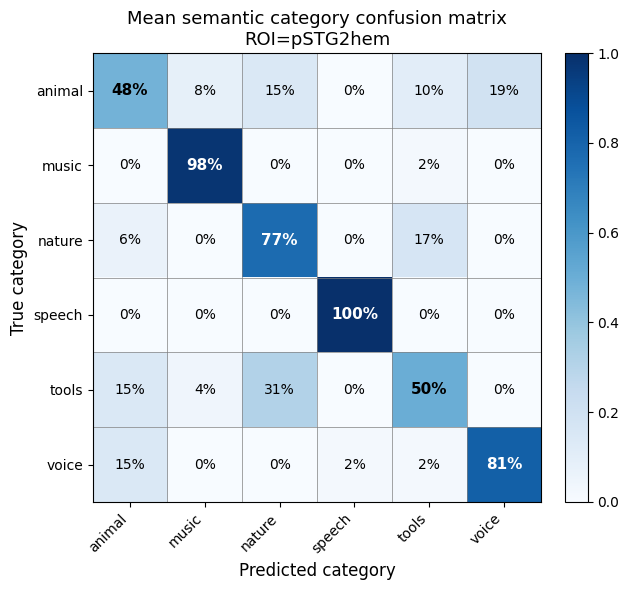

In [144]:
plot_roi_category_confusion(
    semantic_roi_mean_confusion_matrices,
    roi="pSTG2hem",
    class_names=semantic_label_encoder.classes_
)

In [145]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import re


# =========================================================
# HELPERS
# =========================================================

def extract_semantic_category(sound_name: str) -> str:
    m = re.match(r"stim\d+_cat\d+_([a-zA-Z]+)_exemp\d+", str(sound_name))
    if m is None:
        raise ValueError(f"Formato inatteso per sound name: {sound_name}")
    return m.group(1).lower()


def average_test_by_sound(X_test, test_sounds):
    unique_sounds = np.unique(test_sounds)

    X_test_avg = []
    test_sounds_avg = []

    for s in unique_sounds:
        idx = np.where(test_sounds == s)[0]
        X_test_avg.append(X_test[idx].mean(axis=0))
        test_sounds_avg.append(s)

    return np.vstack(X_test_avg), np.array(test_sounds_avg)


def zscore_train_test(X_train, X_test):
    train_mean = X_train.mean(axis=0, keepdims=True)
    train_std = X_train.std(axis=0, keepdims=True)
    train_std[train_std == 0] = 1.0

    X_train_z = (X_train - train_mean) / train_std
    X_test_z = (X_test - train_mean) / train_std

    return X_train_z, X_test_z


def concatenate_rois_for_cv(pooled_data, roi_list, cv):
    """
    Concatena tutte le ROI lungo la dimensione dei voxel per un dato CV.
    Restituisce:
        X_train_concat
        X_test_concat
        train_sounds_ref
        test_sounds_ref
    """
    X_train_list = []
    X_test_list = []

    train_sounds_ref = None
    test_sounds_ref = None
    used_rois = []

    for roi in roi_list:
        if roi not in pooled_data or cv not in pooled_data[roi]:
            print(f"[SKIP] ROI={roi}, CV={cv} non presente")
            continue

        entry = pooled_data[roi][cv]

        X_train = np.asarray(entry["X_train"])
        X_test = np.asarray(entry["X_test"])
        train_sounds = np.asarray(entry["train_sounds"]).astype(int).squeeze()
        test_sounds = np.asarray(entry["test_sounds"]).astype(int).squeeze()

        if train_sounds_ref is None:
            train_sounds_ref = train_sounds
            test_sounds_ref = test_sounds
        else:
            if not np.array_equal(train_sounds_ref, train_sounds):
                raise ValueError(f"train_sounds non allineati nella ROI {roi}, CV={cv}")
            if not np.array_equal(test_sounds_ref, test_sounds):
                raise ValueError(f"test_sounds non allineati nella ROI {roi}, CV={cv}")

        X_train_list.append(X_train)
        X_test_list.append(X_test)
        used_rois.append(roi)

    if len(X_train_list) == 0:
        raise ValueError(f"Nessuna ROI valida trovata per CV={cv}")

    X_train_concat = np.concatenate(X_train_list, axis=1)
    X_test_concat = np.concatenate(X_test_list, axis=1)

    return X_train_concat, X_test_concat, train_sounds_ref, test_sounds_ref, used_rois


def plot_confusion_matrix_with_percentages(mat, class_names, title="Confusion matrix", figsize=(7, 6), cmap="Blues"):
    plt.figure(figsize=figsize)
    im = plt.imshow(mat, cmap=cmap, vmin=0, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(range(len(class_names)), class_names)

    plt.xlabel("Predicted category")
    plt.ylabel("True category")
    plt.title(title)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            value = mat[i, j]
            text = f"{value*100:.0f}%"
            color = "white" if value > 0.5 else "black"
            weight = "bold" if i == j else "normal"
            plt.text(j, i, text, ha="center", va="center", color=color, fontsize=10, fontweight=weight)

    plt.tight_layout()
    plt.show()


# =========================================================
# MAIN
# =========================================================

def evaluate_semantic_category_decoding_all_rois(
    pooled_data,
    roi_list,
    cv_list,
    name_sounds,
    C=1.0,
    max_iter=3000,
):
    """
    Per ogni CV:
      - concatena tutte le ROI sui voxel
      - media il test sui soggetti
      - predice la categoria semantica da tutto il pattern neurale concatenato

    Restituisce:
      summary_df
      cv_results_df
      predictions_df
      mean_confusion_matrix
      label_encoder
    """

    # label globali dai nomi dei suoni
    semantic_labels_all = np.array([extract_semantic_category(x) for x in name_sounds])

    label_encoder = LabelEncoder()
    label_encoder.fit(semantic_labels_all)
    class_names = list(label_encoder.classes_)

    print("Semantic classes:", class_names)

    cv_rows = []
    prediction_rows = []
    cv_confusions = []

    for cv in cv_list:
        print(f"\n================ CV: {cv} ================\n")

        # 1) concatena tutte le ROI
        X_train_raw, X_test_raw, train_sounds, test_sounds, used_rois = concatenate_rois_for_cv(
            pooled_data, roi_list, cv
        )

        # 2) media test sui soggetti -> 72 sample
        X_test_avg, test_sounds_avg = average_test_by_sound(X_test_raw, test_sounds)

        # 3) indici globali 0-based
        idx_train = train_sounds - 1
        idx_test = test_sounds_avg - 1

        # 4) categorie semantiche
        y_train_str = semantic_labels_all[idx_train]
        y_test_str = semantic_labels_all[idx_test]

        y_train = label_encoder.transform(y_train_str)
        y_test = label_encoder.transform(y_test_str)

        # 5) z-score
        X_train, X_test = zscore_train_test(X_train_raw, X_test_avg)

        # 6) classificatore
        clf = Pipeline([
            ("clf", LogisticRegression(
                C=C,
                max_iter=max_iter,
                multi_class="multinomial",
                solver="lbfgs",
                class_weight="balanced"
            ))
        ])

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        if hasattr(clf.named_steps["clf"], "predict_proba"):
            y_proba = clf.predict_proba(X_test)
            confidence = np.max(y_proba, axis=1)
        else:
            confidence = np.full(len(y_pred), np.nan)

        # 7) metriche
        acc = accuracy_score(y_test, y_pred)
        bacc = balanced_accuracy_score(y_test, y_pred)

        cm = confusion_matrix(
            y_test,
            y_pred,
            labels=np.arange(len(class_names)),
            normalize="true"
        )

        cv_confusions.append(cm)

        print(
            f"[CV={cv}] X_train={X_train.shape}, X_test={X_test.shape}, "
            f"n_rois={len(used_rois)}, Acc={acc:.4f}, BalancedAcc={bacc:.4f}"
        )

        cv_rows.append({
            "cv": cv,
            "n_train": X_train.shape[0],
            "n_test": X_test.shape[0],
            "n_voxels_total": X_train.shape[1],
            "n_rois_used": len(used_rois),
            "accuracy": float(acc),
            "balanced_accuracy": float(bacc),
        })

        for i in range(len(idx_test)):
            prediction_rows.append({
                "cv": cv,
                "sample_local_idx": int(i),
                "true_sound_idx_1based": int(idx_test[i] + 1),
                "true_sound_name": str(name_sounds[idx_test[i]]),
                "true_category": str(y_test_str[i]),
                "pred_category": str(label_encoder.inverse_transform([y_pred[i]])[0]),
                "correct": bool(y_pred[i] == y_test[i]),
                "confidence": float(confidence[i]),
            })

    # dataframe risultati CV
    cv_results_df = pd.DataFrame(cv_rows)
    predictions_df = pd.DataFrame(prediction_rows)

    # media confusion matrix sui CV
    mean_confusion_matrix = np.mean(np.stack(cv_confusions, axis=0), axis=0)

    # summary finale
    summary_df = pd.DataFrame([{
        "n_cvs": int(len(cv_results_df)),
        "accuracy_mean": cv_results_df["accuracy"].mean(),
        "accuracy_std": cv_results_df["accuracy"].std(ddof=1) if len(cv_results_df) > 1 else 0.0,
        "balanced_accuracy_mean": cv_results_df["balanced_accuracy"].mean(),
        "balanced_accuracy_std": cv_results_df["balanced_accuracy"].std(ddof=1) if len(cv_results_df) > 1 else 0.0,
        "n_voxels_total_mean": cv_results_df["n_voxels_total"].mean(),
    }])

    return summary_df, cv_results_df, predictions_df, mean_confusion_matrix, label_encoder

In [146]:
roi_list = ["PT2hem", "HG2hem", "mSTG2hem", "pSTG2hem", "PP2hem", "aSTG2hem"]
cv_list = ["CV1", "CV2", "CV3", "CV4"]

summary_df, cv_results_df, predictions_df, mean_confusion_matrix, label_encoder = \
    evaluate_semantic_category_decoding_all_rois(
        pooled_data=pooled_data,
        roi_list=roi_list,
        cv_list=cv_list,
        name_sounds=name_sounds,
        C=1.0,
        max_iter=3000
    )

Semantic classes: ['animal', 'music', 'nature', 'speech', 'tools', 'voice']

================ CV: CV1 ================



/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[CV=CV1] X_train=(1080, 6144), X_test=(72, 6144), n_rois=6, Acc=0.6944, BalancedAcc=0.6944

================ CV: CV2 ================



/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[CV=CV2] X_train=(1080, 6144), X_test=(72, 6144), n_rois=6, Acc=0.8333, BalancedAcc=0.8333

================ CV: CV3 ================



/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[CV=CV3] X_train=(1080, 6144), X_test=(72, 6144), n_rois=6, Acc=0.8472, BalancedAcc=0.8472

================ CV: CV4 ================

[CV=CV4] X_train=(1080, 6144), X_test=(72, 6144), n_rois=6, Acc=0.7778, BalancedAcc=0.7778


/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [148]:
print(summary_df)
print(cv_results_df)

   n_cvs  accuracy_mean  accuracy_std  balanced_accuracy_mean  \
0      4       0.788194      0.069329                0.788194   

   balanced_accuracy_std  n_voxels_total_mean  
0               0.069329               6144.0  
    cv  n_train  n_test  n_voxels_total  n_rois_used  accuracy  \
0  CV1     1080      72            6144            6  0.694444   
1  CV2     1080      72            6144            6  0.833333   
2  CV3     1080      72            6144            6  0.847222   
3  CV4     1080      72            6144            6  0.777778   

   balanced_accuracy  
0           0.694444  
1           0.833333  
2           0.847222  
3           0.777778  


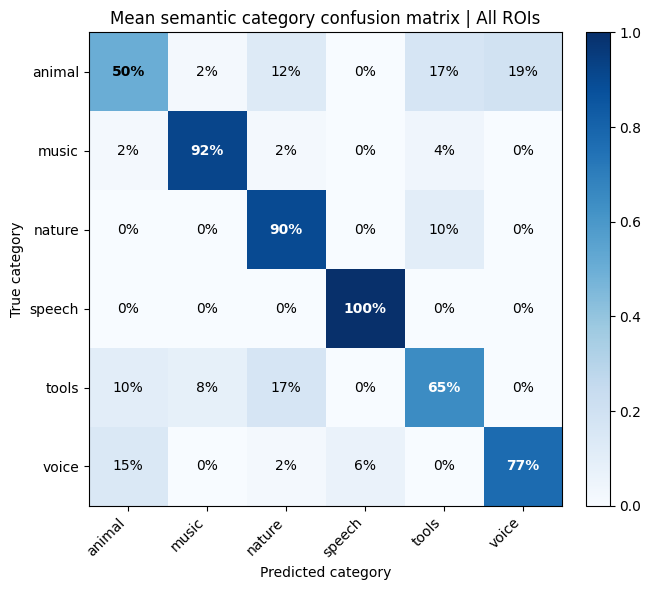

In [147]:
class_names = list(label_encoder.classes_)

plot_confusion_matrix_with_percentages(
    mean_confusion_matrix,
    class_names,
    title="Mean semantic category confusion matrix | All ROIs"
)

## Attention Maps

In [318]:
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import EarlyStopping
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F


class SoftMapping(pl.LightningModule):
    def __init__(self, input_dim=1024, output_dim=512, lr=1e-3, 
                 tau=0.05, loss_type="contrastive", projector_type="linear"):   # 1e-3 
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 768),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(768, output_dim)
        )
        self.attn_linear = nn.Sequential(
            nn.Linear(input_dim, 1),
            nn.Dropout(0.5)
        )
        self.line = nn.Sequential(
            nn.Linear(input_dim, output_dim)
        )
        self.loss_mse = nn.MSELoss()
        self.lr = lr
        self.tau = tau
        self.loss_type = loss_type
        self.projector_type = projector_type
        self.log_tau = nn.Parameter(torch.tensor(np.log(tau), dtype=torch.float32))

    def forward(self, x):     # shape: (batch, 200, 1024)
        # attn_weights = torch.softmax(self.attn_linear(x), dim=1)
        attn_weights = torch.sigmoid(self.attn_linear(x))
        # attn_weights = attn_weights / attn_weights.sum(dim=1, keepdim=True)
        attn_out = torch.mean(attn_weights * x, dim=1)                         # TODO: sum or mean
        if self.projector_type == "mlp":    
            output = self.mlp(attn_out)
        else:
            output = self.line(attn_out)
        return output, attn_weights

    def cosine_similarity_matrix(self, A, B):
        A_norm = F.normalize(A, dim=1)
        B_norm = F.normalize(B, dim=1)
        return torch.mm(A_norm, B_norm.T)
    
    def ridge_loss(self, y_pred, y_true, alpha):
        mse = F.mse_loss(y_pred, y_true)
        l2_reg = sum(param.pow(2).sum() for param in self.parameters())
        num_params = sum(param.numel() for param in self.parameters())
        l2_reg = l2_reg / num_params
        return mse + alpha * l2_reg

    def contrastive_loss_nt(self, S, tau):
        tau = torch.exp(self.log_tau)  
        S_exp = torch.exp(S / tau)
        loss = -torch.log(torch.diag(S_exp) / S_exp.sum(dim=1))
        return loss.mean()

    def training_step(self, batch, batch_idx):
        x, y = batch
        # loss = self.loss_fn(self(x), y)
        output, attn_weights = self(x)
        if self.loss_type == "mse":
            loss = self.loss_mse(output, y)
        else:
            cos_matrix = self.cosine_similarity_matrix(output, y)
            loss = self.contrastive_loss_nt(cos_matrix, self.tau)

        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        self.log("tau", torch.exp(self.log_tau).item(), prog_bar=True)  
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        output, attn_weights = self(x)
        if self.loss_type == "mse":
            loss = self.loss_mse(output, y)
        else:
            cos_matrix = self.cosine_similarity_matrix(output, y)
            loss = self.contrastive_loss_nt(cos_matrix, self.tau)

        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        return loss
 
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=1e-4)   # 1e-4

In [319]:
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import random_split
import torch

batch_size = 32
cuda_d = 7
device = torch.device(f"cuda:{cuda_d}" if torch.cuda.is_available() else "cpu")

X_train = X_train_concat
Y_train = torch.Tensor(train_audio_embeds)
X_test = X_test_avg
Y_test = torch.Tensor(test_audio_embeds)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

mean = X_train_tensor.mean(dim=(0,1), keepdim=True)
std = X_train_tensor.std(dim=(0,1), keepdim=True, unbiased=False) + 1e-6

X_train_tensor = (X_train_tensor - mean) / std
X_test_tensor = (X_test_tensor - mean) / std

dataset = TensorDataset(X_train_tensor, torch.tensor(Y_train, dtype=torch.float32))
test_dataset = TensorDataset(X_test_tensor, torch.tensor(Y_test, dtype=torch.float32))
val_size = int(0.1 * len(dataset))  
train_size = len(dataset) - val_size
generator1 = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=generator1)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



/tmp/ipykernel_3851313/408188200.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dataset = TensorDataset(X_train_tensor, torch.tensor(Y_train, dtype=torch.float32))
/tmp/ipykernel_3851313/408188200.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_dataset = TensorDataset(X_test_tensor, torch.tensor(Y_test, dtype=torch.float32))


In [320]:
seed = 42     # 42, 55, 5, 1, 9999
pl.seed_everything(seed, workers=True)
attn_model = SoftMapping(loss_type='contrastive', projector_type='linear', lr=1e-3, tau=0.05)
early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=0.09, patience=6, verbose=True, mode="min")
trainer = Trainer(max_epochs=50, devices=[cuda_d], callbacks=[early_stop_callback])  
trainer.fit(attn_model, train_loader, val_loader)

Seed set to 42
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/matteoc/miniconda3/envs/huggin/lib/python3.11/ ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]

  | Name         | Type       | Params
--------------------------------------------
0 | mlp          | Sequential | 1.2 M 
1 | attn_linear  | Sequential | 1.0 K 
2 | line         | Sequential | 524 K 
3 | loss_mse     | MSELoss    | 0     
  | other params | n/a        | 1     
--------------------------------------------
1.7 M     Trainable params
0         Non-trainable params
1.7 M     Total params
6.827     Total e

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=255` in the `DataLoader` to improve performance.
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=255` in the `DataLoader` to improve performance.
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/pytorch_lightning/loops/fit_loop.py:293: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 6 records. Best score: 2.685. Signaling Trainer to stop.


In [321]:
x,y = next(iter(test_loader))

y_pred=[]
y_true=[]
attn_weights_list = []

attn_model.eval()
attn_model.to(device)
with torch.no_grad():
    for x,y in tqdm.tqdm(test_loader):
        x = x.to(device)
        y = y.to(device)
        y_hat, attn_weights = attn_model(x) 
        y_true.append(y)
        y_pred.append(y_hat)
        attn_weights_list.append(attn_weights.cpu())

y_pred=torch.cat(y_pred,0)
y_true=torch.cat(y_true,0)
attn_weights_test = torch.cat(attn_weights_list, dim=0).squeeze(-1)

100%|██████████| 3/3 [00:00<00:00, 601.10it/s]


In [322]:
from sklearn.neighbors import NearestNeighbors

y_true_np = y_true.cpu().numpy()
y_pred_np = y_pred.cpu().numpy()
nbrs = NearestNeighbors(n_neighbors=5, metric='cosine').fit(y_true_np)

distances, top_indices = nbrs.kneighbors(y_pred_np)
true_indices = torch.arange(len(y_true_np)).cpu().numpy()

top1_count = (top_indices[:, 0] == true_indices).sum()
top3_count = sum(true_idx in top_indices[i] for i, true_idx in enumerate(true_indices))

print(f"Top-1 accuracy: {top1_count}/{len(y_true_np)} ({top1_count / len(y_true_np) * 100:.2f}%)")
print(f"Top-5 accuracy: {top3_count}/{len(y_true_np)} ({top3_count / len(y_true_np) * 100:.2f}%)")

Top-1 accuracy: 15/72 (20.83%)
Top-5 accuracy: 43/72 (59.72%)


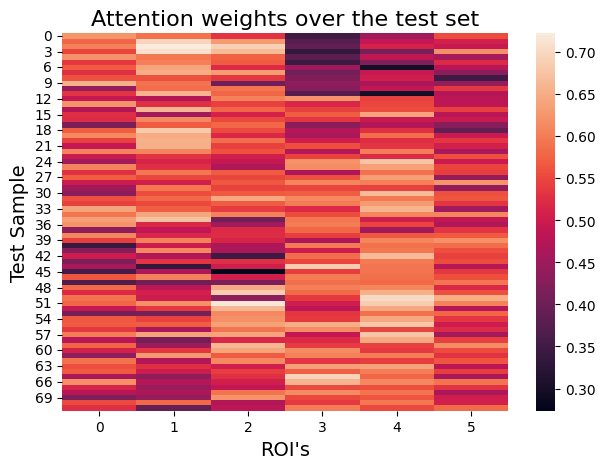

In [323]:
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

neuroposter_cmap = LinearSegmentedColormap.from_list('Neuroposter', (
    # Edit this gradient at https://eltos.github.io/gradient/#Neuroposter=3C0080-9A5598-CFD357
    (0.000, (0.235, 0.000, 0.502)),
    (0.500, (0.604, 0.333, 0.596)),
    (1.000, (0.812, 0.827, 0.341))))

sns.heatmap(attn_weights_test, cmap='rocket')
plt.title("Attention weights over the test set", fontsize=16)
plt.xlabel("ROI's", fontsize=14)
plt.ylabel("Test Sample", fontsize=14)
plt.tight_layout()
plt.show()

In [324]:
import numpy as np
import matplotlib.pyplot as plt

def plot_category_roi_attention_heatmap(
    attention_weights,
    category_names=None,
    roi_names=None,
    samples_per_category=12,
    figsize=(8, 6),
    cmap="magma"
):
    """
    attention_weights: array shape (72, 6)
    Le righe sono ordinate per categoria in blocchi consecutivi.
    """

    attention_weights = np.asarray(attention_weights)

    if category_names is None:
        category_names = ["speech", "voice", "animals", "music", "nature", "tools"]

    if roi_names is None:
        roi_names = ["HG2hem", "PT2hem", "PP2hem", "mSTG2hem", "pSTG2hem", "aSTG2hem"]

    n_categories = len(category_names)
    n_rois = len(roi_names)

    expected_shape = (n_categories * samples_per_category, n_rois)
    if attention_weights.shape != expected_shape:
        raise ValueError(f"Shape attesa {expected_shape}, trovata {attention_weights.shape}")

    # (6, 12, 6) -> media sui 12 sample
    attn_by_cat = attention_weights.reshape(n_categories, samples_per_category, n_rois).mean(axis=1)

    plt.figure(figsize=figsize)
    im = plt.imshow(attn_by_cat, aspect="auto", cmap=cmap)
    plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.xticks(range(n_rois), roi_names, rotation=45, ha="right")
    plt.yticks(range(n_categories), category_names)

    plt.xlabel("ROI")
    plt.ylabel("Category")
    plt.title("Mean attention weights by category and ROI")

    # valori dentro le celle
    for i in range(n_categories):
        for j in range(n_rois):
            value = attn_by_cat[i, j]
            color = "white" if value < attn_by_cat.max() * 0.6 else "black"
            plt.text(j, i, f"{value:.2f}", ha="center", va="center", color=color, fontsize=10)

    plt.tight_layout()
    plt.show()

    return attn_by_cat

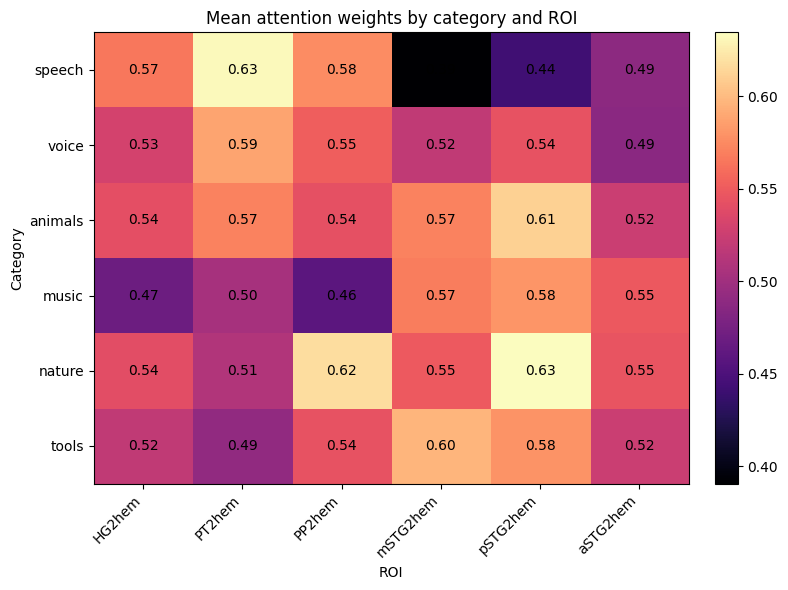

In [325]:
category_names = ["speech", "voice", "animals", "music", "nature", "tools"]
roi_names = ["HG2hem", "PT2hem", "PP2hem", "mSTG2hem", "pSTG2hem", "aSTG2hem"]

attn_by_cat = plot_category_roi_attention_heatmap(
    attn_weights_test,
    category_names=category_names,
    roi_names=roi_names,
    samples_per_category=12,
    figsize=(8, 6),
    cmap="magma"
)